<h1 align="center">Module 2 - LLM Foundations</h1>
<h3 align="center">AI Engineering</h3>

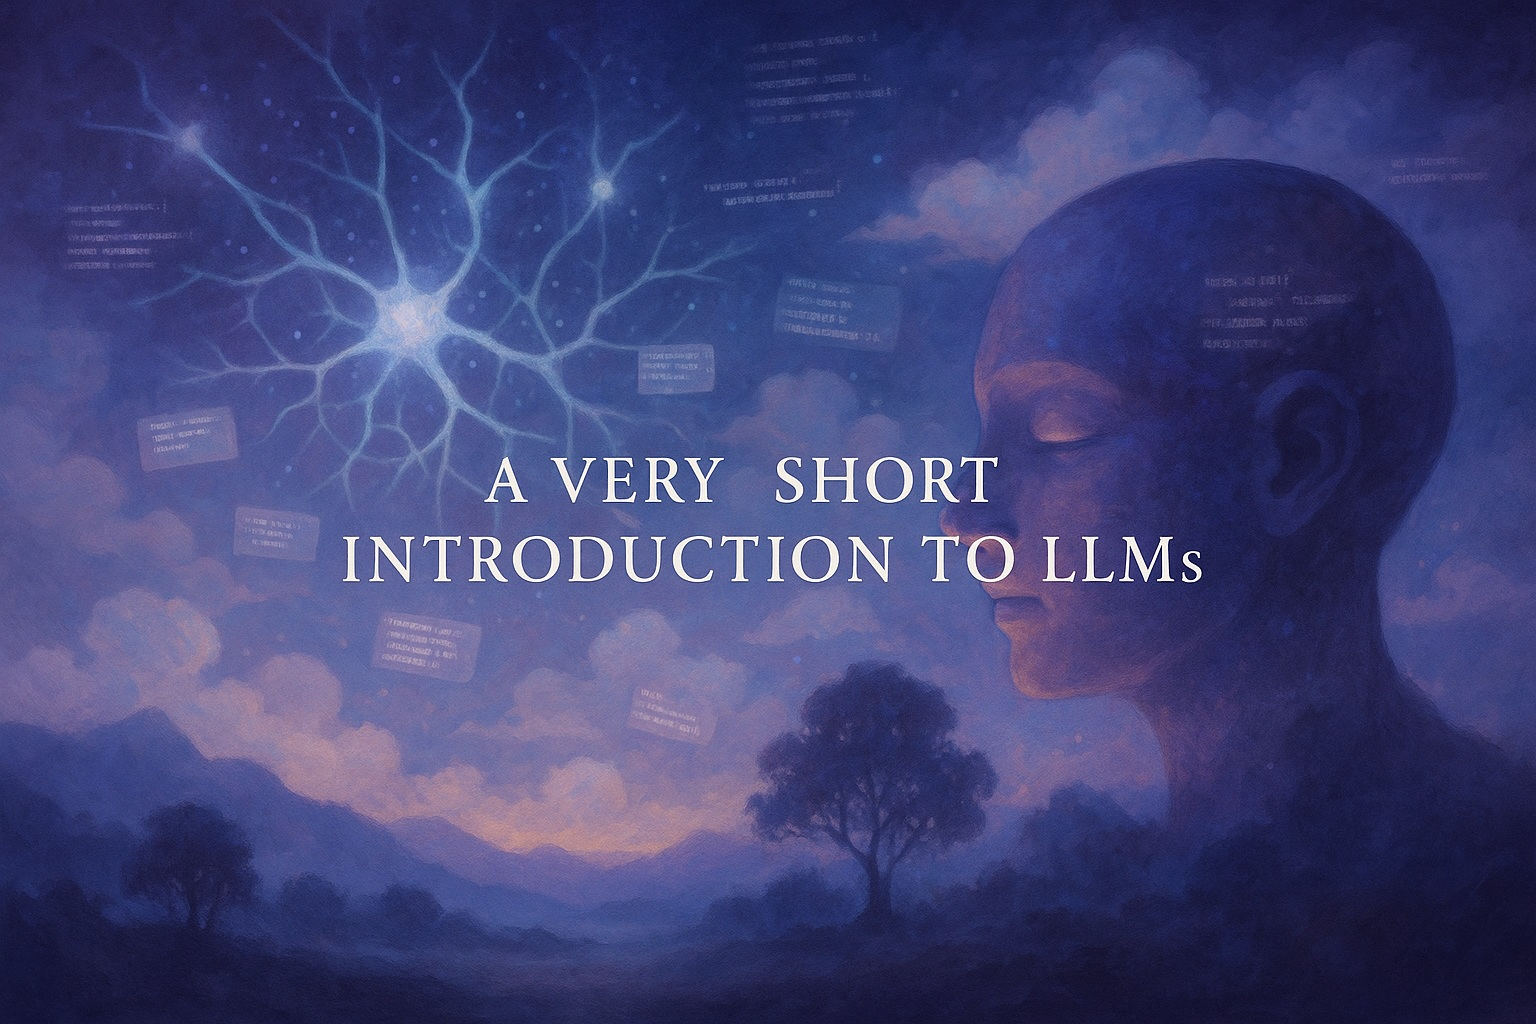

This notebook provides the LLM foundations needed for the rest of the **Junior AI Engineer** course. The goal is not to train a foundation model or implement a Transformer from scratch. The goal is to build a practical mental model of what LLMs do, how text becomes model input, how next-token generation works, and how common libraries expose these capabilities in code.

By the end of the core path, you should be able to explain and work with:

- tokenization and tokens,
- next-token prediction,
- embeddings,
- the Transformer architecture at a conceptual level,
- common LLM architecture families,
- pre-training, fine-tuning, and RLHF at a working level,
- inference controls such as temperature, top-k, and top-p,
- Hugging Face tokenizers, pipelines, chat templates, and generation.

  
> **Scope note:** Application prompting, structured outputs, RAG, agents, reliability, deployment, and LLMOps are intentionally taught in later modules. Here we focus on the model concepts and APIs those topics build on.

# What is an LLM?

A Large Language Model (LLM) is a type of artificial intelligence (AI) that uses deep learning to understand, generate, and process text - human-like. It is able to capture long-range dependencies between words, enabling immeasurably better contextual understanding compared to previous generation models (LSTM-based architectures). LLMs are trained on massive amounts of text data to recognize complex patterns and relationships in language, enabling them to perform a variety of language-related tasks.

### Tasks

LLMs excel at a wide variety of language tasks, including:

* ***Sentiment Analysis***
* ***Named Entity Recognition (NER)*** identify predefined categories of objects in text (e.g., "*Tomer*" --> person, "*Nvidia*" --> company).
* ***Question Answering***: given a context, answer a question (no external knowledge)
* ***Text Generation / Instruct***: generate human-like text for chatbots and other content generation tasks, following a prompt.
* ***Translation***
* ***Summarization***

While LLMs like *ChatGPT*, *DeepSeek* and *Gemini* (and many others) are general purpose, it's common to have LLMs specialize on one specific task. As we'll see later on, specializing an LLM is often called *fine-tuning*. 

# The Makeup of an LLM

To understand how LLMs work, we need to understand, at a minimum, these four ideas and components:

## 1. Tokenization

Before an LLM can process text, it must convert words into standardized building blocks called tokens. *Tokenization* is the process that splits a text into these smaller units - words, subwords, or even characters, and assigns each a unique integer ID from the model's vocabulary.

> ➡️ Think about it like this: Tokenization is like breaking language down into, more manageable, Lego-like pieces. The LLM doesn't see sentences - it sees sequences of tokens, each assigned an ID. Downstream, those ID will be replaced by a vectorized representation, an embedding.

#### Why Tokenization Exists

Computers can't process text directly - they need numbers. But language is messy:

- "dog" and "dogs" are related but not identical.
- Compound words, names, emojis, and punctuation vary wildly.
- Many languages use inflections (boy/boy's, walk/walked, big/bigger), prefixes (ex-partner, pre-existing), and suffixes (quickly, running) that make word-based models inefficient (think about assigning a unique number to each and every word variation in the vocabulary).

To handle this, LLMs use tokenizers that map text to a finite set of reusable **tokens**. This allows the model to:

- Generalize across related words ("run", "running", "runner").
- Keep the vocabulary manageable (tens of thousands instead of millions, if we tried to assign a token to all the variations of all the words).
- Handle any text, including rare words, names or typos, by decomposing them (did you ever wonder how LLMs manage names and words they have never seen before? - Well, now you know...)

 ### 👉 **[The Tokenizer Playground](https://huggingface.co/spaces/Xenova/the-tokenizer-playground)**

#### How it Works

1. **Text normalization**: Converts text to a consistent format (lower-casing, Unicode normalization, etc.).
2. **Splitting**: Breaks the text into segments (e.g., “unbelievable” → “un”, “believ”, “able”).
3. **Mapping**: Each segment is mapped to a token ID from the vocabulary.
4. **Sequence creation**: The text *“The cat sat on the mat.”* might become something like `[1834, 2421, 911, 556, 1834, 6322, 13]`.

When decoding, the reverse happens - token IDs are mapped back to text.

> **Notes:**
> - Most modern LLMs (GPT, Llama, Mistral) use **Byte Pair Encoding (BPE)** or similar algorithms like SentencePiece to find optimal subword units. See **[here](https://medium.com/data-science/byte-pair-encoding-subword-based-tokenization-algorithm-77828a70bee0)** and **[here](https://huggingface.co/learn/llm-course/en/chapter6/5)**.
> - The word-to-token ratio is, roughly, 1:1.33 (i.e., for every 10 words, we get 13 or 14 tokens, on average).
> - OpenAI's *GPT-5* model has a vocabulary of 272,000 tokens, covering many different languages.

## 2. LLMs Are, Fundamentally, Classification Models

At their core, Large Language Models (LLMs) are *giant probabilistic classifiers*. When an LLM receives a sequence of input tokens, it tries to predict **the most likely next token**. It outputs a **vector of probabilities** - probability for each token in the vocabulary. A token's probability is an indication of **how likely it is to be the next token** in the sequence of tokens.

So in essence:

<center>
    <h3>
        Given the context so far, which token should come next - and how confident am I about it?
    </h3>
</center>
<br/>

<center>
    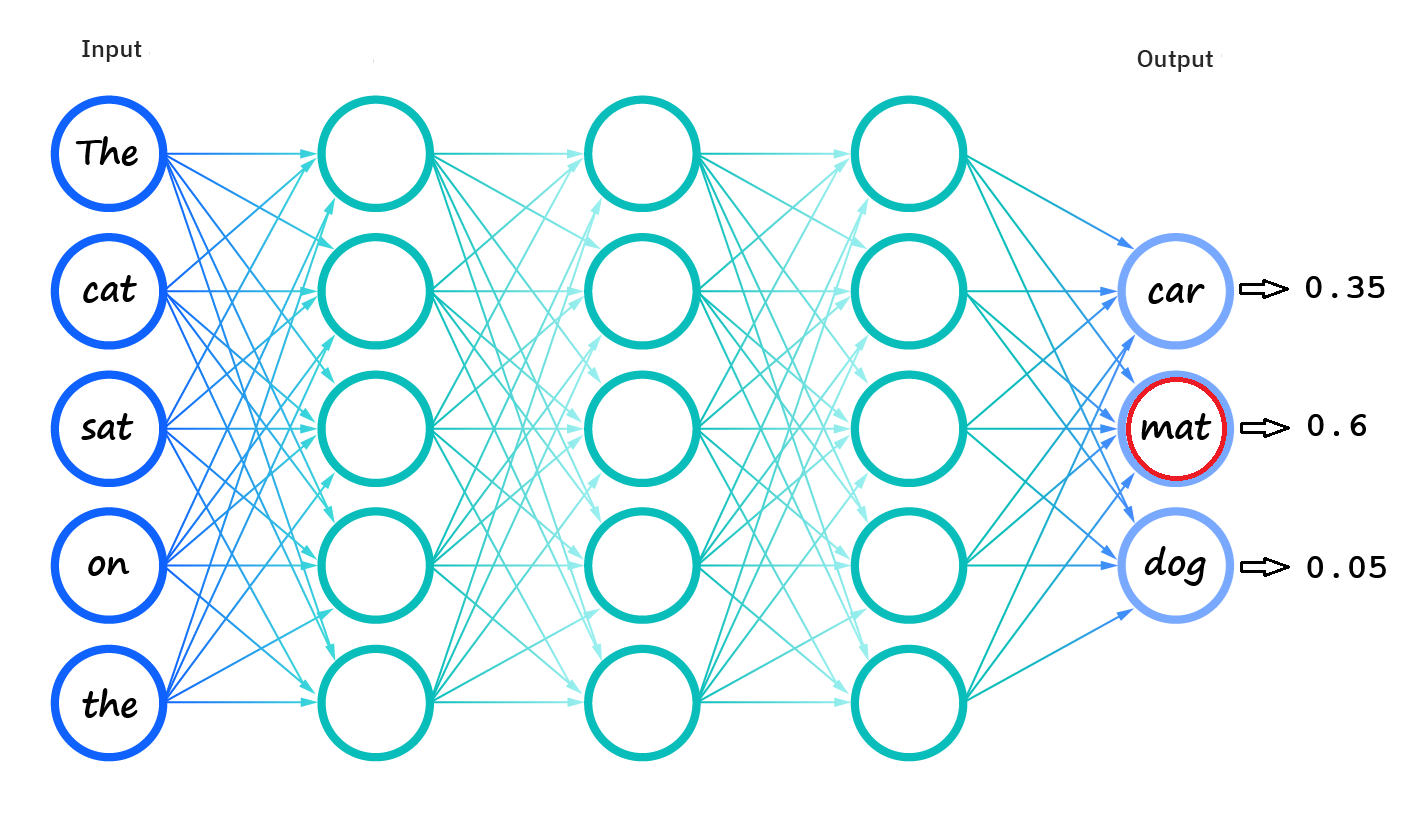
</center>

Next token classification is repeated many times in a row:

- *Input*: the prompt + generated response, so far
- *Output*: a probability distribution over all vocabulary tokens
- The predicted token (the one with the highest probability, or sampled - we'll see later) is then appended to the input sequence
- Repeat, until a special "termination" token is generated.

<br/>

<center>
<h3>
This is how text generation emerges from classification - one token at a time!.
</h3>
</center>

> ➡️ **Note**: These kind of models are sometimes called "auto-regressive models".

> ➡️ **Important**: A token's ID also the *index* (location) of the token in the vocabulary. The LLM's *output* layer is ordered the exact same way as the vocabulary, meaning that an output node's *index* corresponds with a token's vocabulary index. 

## 3. Token Embeddings

We've already mentioned that computers can't directly work with words or characters - they require numbers. But token IDs are not enough, because plain ID numbers **do not capture the semantics** (meaning) of a token nor the relationship between tokens (if any). **Token embedding** is how LLMs translate discrete symbols (like "cat" or "economy") into dense numerical vectors that **capture meaning**.

#### Intuition

* Imagine each word is placed in a high-dimensional space (say, 1,024 dimensions).
* Every dimension (axis) in that space represents some unique semantic meaning / quality - "Age", "Gender" and "Royalty", in our example (in practice, we have no clue what a single dimension represents...).
* Related words are closer together in that space.
* To find out how related two words are, we calculate the dot-product of their representative vectors. **The higher the product is, the more related the words are**.
* The embedding captures not just meaning, but also grammatical and contextual relationships. E.g., *Jerusalem* is close to *London*, and $\large \vec{v}King - \vec{v}Man + \vec{v}Woman ≈ \vec{v}Queen$

<center>
<table>
    <tr>
        <td>
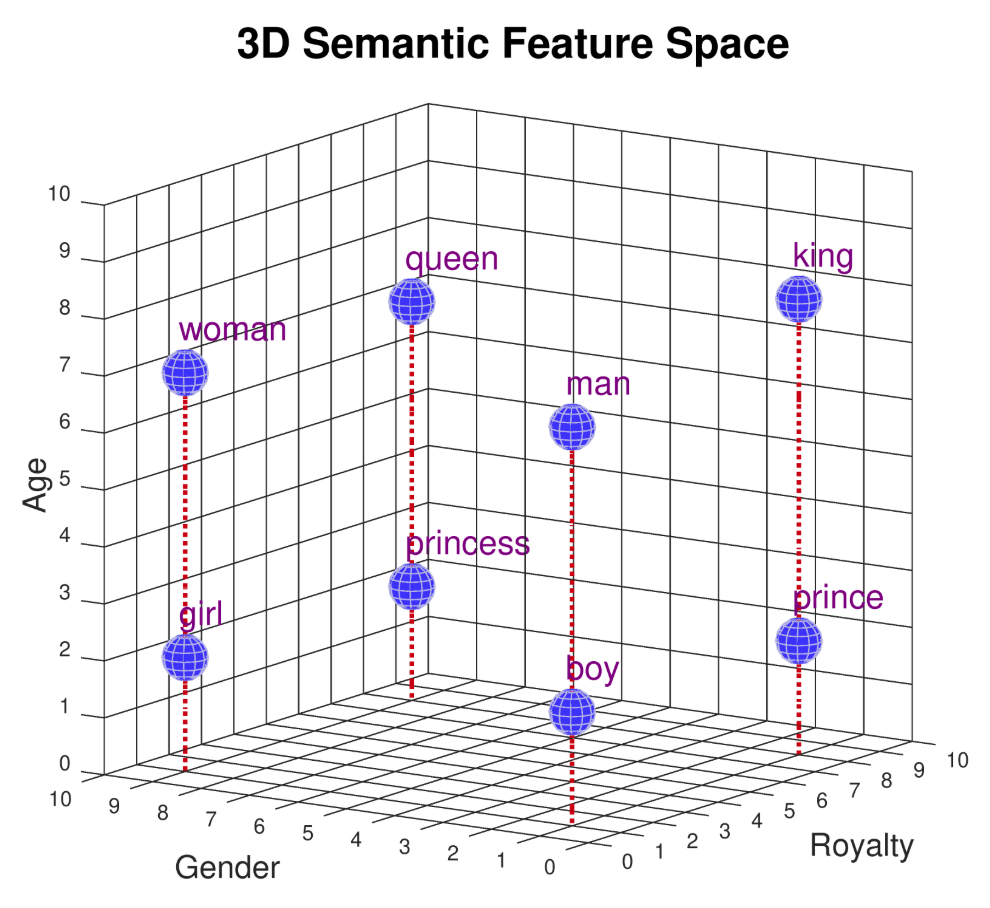
        </td>
        <td>
            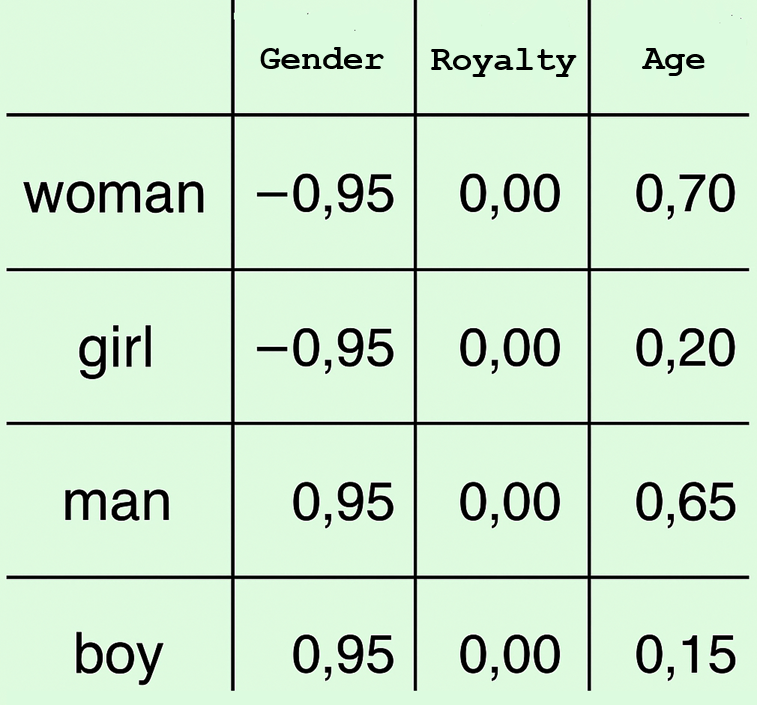
        </td>
    </tr>
</table>
</center>
<center>
    <h6>
        <a href="https://www.cs.cmu.edu/~dst/WordEmbeddingDemo/tutorial.html">Source: Carnegie Mellon University</a>
    </h6>
</center>

> 🧮 Lets take an interlude and calculate these products (you'll see why shortly):
> 
> $\large \text{woman * girl =}$ (-0.95 * -0.95) + (0.0 * 0.0) + (0.7 * 0.2)  $\large = 1.0425$
>
> $\large \text{man * girl =}$ (0.95 * -0.95) + (0.0 * 0.0) + (0.65 * 0.2)   $\large = -0.7725$
>
> For now, just notice that closely related words ("woman", "girl") have higher product values than unrelated / less related words ("man", "girl"). 

#### Why Embedding Matters?

* Embeddings give the model a *continuous representation* of language - meaning tiny changes in the numbers represent subtle changes in meaning.
* Neural networks learn by adjusting numbers gradually through optimization. You cannot do that if your inputs are discrete IDs (like 12, 435, or 911). Embeddings make language differentiable - allowing backpropagation (Gradient Descent) to tune the model effectively.
* They form the foundation upon which the Transformer layers build - the rest of the model only sees these embeddings, not words. The Transformer layers works **entirely on embeddings**. The Transformer doesn't know what "cat" or "happiness" mean as words - it only processes vectors whose geometry encodes those meanings.

In many cases, model families (Meta's Llama, OpenAI's GPT, Mistral, etc.) use their own embeddings (as opposed to using publicly available embeddings). Embedding length (dimensionality) is typically in the thousands (e.g., Gemini3 - 3072, Llama4 - 5120, DeepSeek V3 - 7,168).

#### 💥 [Word Embedding Demo](https://www.cs.cmu.edu/~dst/WordEmbeddingDemo/)

And, just in case you were wondering how embeddings are derived to begin with:

#### 👉 [LLM Embeddings Explained: A Visual and Intuitive Guide](https://huggingface.co/spaces/hesamation/primer-llm-embedding)

## 4. The *Transformer* Architecture

The Transformer architecture revolutionized Natural Language Processing (NLP) by enabling efficient, context-aware modeling of sequences without relying on recurrence (RNN-family) or convolution (CNN-family). The architecture, introduced by Vaswani et al. (2017) in the seminal **[👉 "Attention Is All You Need"](https://proceedings.neurips.cc/paper_files/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf)** paper, is now the backbone of modern LLMs (and not just LLMs...).

#### Core Idea

Transformers are designed to capture **relationships between all the tokens in a sequence**, regardless of their distance from each other.

Older architectures (like RNNs or LSTMs) read text sequentially, one-token-at-a-time, which made it hard to capture long-range dependencies.<br/>
Transformers instead use a **self-attention** mechanism (below), allowing the model to **look at all other tokens at once** and decide which are most relevant for understanding the current one.

This mechanism enables:
* *Contextual meaning*: understanding that $\large \text{bank}$ means different things in $\large \text{river  bank}$ vs. $\large \text{central bank}$.
* *Long-range reasoning*: connecting entities across long texts.

#### Key Components of the Transformer (in order)

***Tokenization***: Text is split into tokens (as we saw).

***Input Embedding***: Tokens are converted into numerical vectors (embeddings) capturing token-level semantics (as we saw).

***Positional Encoding***: Since Transformers process sequences in parallel, positional encoding are added to embeddings to capture a token's order in the sequence.

***Self-Attention Mechanism***: This is the core innovation. Every token can "attend" to every other token in the sequence, allowing the model to capture contextual relationships regardless of how far the tokens are apart in the input.

<center>
    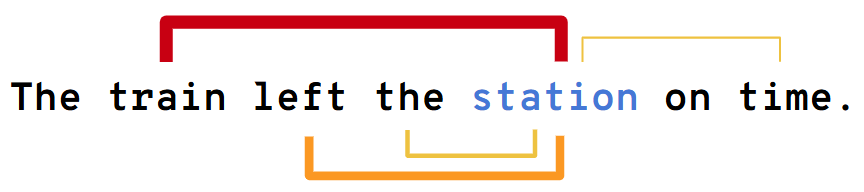    
</center>


<br/>
<center>
    <img width="1100" src="https://drek4537l1klr.cloudfront.net/chollet2/HighResolutionFigures/figure_11-6.png" />    
</center>
<center>
    <a href=https://livebook.manning.com/book/deep-learning-with-python-second-edition/chapter-11/243>source</a>
</center>

> 💡 In effect, each token "pays attention" to other tokens, weighted by how relevant they are in context.  
> This is also how multi-meaning words get their unique representation. Like the word "Bank" (or "Even", ...). Embedding-wise, the word "Bank" is the same, no matter the context. The sentence "I went to the bank." is ambiguous to humans and LLMs alike. But given some additional context, the ambiguity dissolves - "I went to the bank to make a withdrawal." And there lies the beauty of the attention mechanism - by compounding the impact of context words on the word "bank", we get a new representation of the word which clearly separates it semantically from the meaning of "bank" in a sentence like "I went to the bank to catch fish." 

***Multi-Head Attention***: Multiple self-attention "heads" run in parallel, each learning different aspects of the relationships between tokens.

***Feed-forward Neural Networks***: After attention, each token's representation is independently passed through a small neural network (MLP) for further transformation.

***Layer Normalization & Residual Connections***: These techniques stabilize training and allow for deeper networks by helping gradients flow more effectively.

***Encoder-Decoder Structure***: The classic Transformer consists of an *Encoder* stack and a *Decoder* stack. *Encoders* process the input sequence, while *Decoders* generate the output sequence, often used for tasks like translation.

***Output Layer***: A final linear and `softmax`-ed layer produces **probabilities for every token**, with the highest probability indicating the most likely token to come next.

> *Additional resources on transformers and attention*:
> #### 👉 [Basic self-attention implementation (GitHub)](https://github.com/ranfysvalle02/ai-self-attention)
> #### 👉 [BertViz (self attention visualization)](https://github.com/jessevig/bertviz?tab=readme-ov-file)
> #### 👉 [The Illustrated Transformer](https://jalammar.github.io/illustrated-transformer/)
> #### 👉 [Understanding Attention in Transformers, with code](https://medium.com/@shubham.ksingh.cer14/understanding-attention-in-transformers-with-code-1ddd6c07abf4)
> #### 👉 [Multi-Head Attention Mechanism](https://www.geeksforgeeks.org/nlp/multi-head-attention-mechanism/) and also [Multi-head Attention, deep dive](https://medium.com/data-science/transformers-explained-visually-part-3-multi-head-attention-deep-dive-1c1ff1024853)
> #### 👉 💥 An ***amazing***, but highly technical, interactive visualization of an LLM's inner-workings: [LLM Visualization](https://bbycroft.net/llm)

#### Why Transformers Excel

1. ***Parallelization***: Unlike RNNs, Transformers process all tokens at once, making them faster and more scalable.
2. ***Context Awareness***: Self-attention enables understanding of long-range dependencies in text.
3. ***Flexibility***: The architecture (can be adapted for various tasks, including translation, summarization, and general text generation.

> **Note**: you may be asking what happens if the context (input text) keeps on growing.
> * Does it make sense to compute the attention score between every token and every other token in a 100,000 tokens long context?
> * What about the growing resource usage (computation, memory)? Response time?
> * Or worse, why would we even want to compute scores for tokens far away from one another (they, likely, don't impact one another)?
> * Lastly, computing a token's context-aware vector while  taking into account too many tokens means that each token (even related ones) would have negligible impact overall.
>  
> Well, good that you've mentioned it. While the original self-attention mechanism is a "talk to everyone" algorithm, models handling extremely long contexts use more sophisticated, efficient variations. One family of solutions is called *Sparse Attention*. Members of this family include *Local Attention* which restricts attention to a fixed-size window around each token. Another approach is *Hierarchical Attention* which breaks down the long context into smaller segments and applies attention within each segment, then applies another layer of attention over the summarized representations of these segments. Yet another approach is *compacting*/*summarizing* past context, shrinking the context to a minimum (eliminating the problem at the source, but at the potential expense of some detail loss). There are other methods, of course.

### LLM Architectures

There are three common architecture families based on the Transformer idea. They differ in one crucial way:

> ***When processing a token, what other tokens is the model allowed to look at?***

This affects what the model learns to do well.

- If a model can look at the whole input at once, it is good at **understanding** text.
- If a model must generate text left-to-right, it is good at **continuing** text.
- If a model first reads one text and then generates another, it is good at **transforming** text.

#### Common LLM architecture families

<br/>
<table width="75%" border="1" cellspacing="2" cellpadding="3" class="wc">
<thead>
    <tr bgcolor="#BBDDBB" align="left">
        <td><strong>Architecture</strong></td>
        <td><strong>Core intuition</strong></td>
        <td><strong>What can each token see?</strong></td>
        <td><strong>Typical training objective</strong></td>
        <td><strong>Notable models</strong></td>
        <td><strong>Common use cases</strong></td>
        <td><strong>Chat suitability</strong></td>
    </tr>
</thead>
<tbody>
    <tr>
        <td><strong>Encoder-only</strong></td>
        <td>
            <strong>Reader / understander</strong><br/>
            Builds a rich representation of the input text.
        </td>
        <td>
            Bidirectional context:<br/>
            each token can look left and right, so the model can use the whole input.
        </td>
        <td>
            Often <strong>masked language modeling</strong>: hide some tokens and ask the model to recover them.
        </td>
        <td>
            <ul>
                <li>BERT</li>
                <li>RoBERTa</li>
                <li>DeBERTa</li>
                <li>Many embedding models</li>
            </ul>
        </td>
        <td>
            <ul>
                <li>Text classification</li>
                <li>Sentiment analysis</li>
                <li>Named entity recognition</li>
                <li>Semantic search / embeddings</li>
                <li>Reranking</li>
                <li>Extractive question answering</li>
            </ul>
        </td>
        <td>
            Weak by itself.<br/>
            It understands text well, but it is not naturally trained to generate long free-form answers.
        </td>
    </tr>
    <tr>
        <td><strong>Decoder-only</strong></td>
        <td>
            <strong>Writer / completer</strong><br/>
            Continues a sequence one token at a time.
        </td>
        <td>
            Causal, left-to-right context:<br/>
            each token can only look at previous tokens.
        </td>
        <td>
            <strong>Next-token prediction</strong>: given the previous tokens, predict the next token.
        </td>
        <td>
            <ul>
                <li>GPT-style models</li>
                <li>Llama</li>
                <li>Mistral</li>
                <li>Gemma</li>
                <li>Claude-style and many modern chat LLMs</li>
            </ul>
        </td>
        <td>
            <ul>
                <li>Chat assistants</li>
                <li>Text generation</li>
                <li>Code generation</li>
                <li>Instruction following</li>
                <li>Tool-using agents</li>
                <li>In-context learning</li>
            </ul>
        </td>
        <td>
            Very strong.<br/>
            A chat conversation can be represented as a long prompt, and the model continues it by generating the assistant's next tokens.
        </td>
    </tr>
    <tr>
        <td><strong>Encoder-decoder</strong></td>
        <td>
            <strong>Reader + writer</strong><br/>
            Reads one text, then generates another text.
        </td>
        <td>
            The encoder reads the full input bidirectionally.<br/>
            The decoder generates the output left-to-right while attending to the encoded input.
        </td>
        <td>
            Usually <strong>sequence-to-sequence</strong> or <strong>text-to-text</strong> training.
        </td>
        <td>
            <ul>
                <li>T5</li>
                <li>FLAN-T5</li>
                <li>BART</li>
                <li>mBART</li>
            </ul>
        </td>
        <td>
            <ul>
                <li>Translation</li>
                <li>Summarization</li>
                <li>Rewriting</li>
                <li>Question answering</li>
                <li>Structured text-to-text tasks</li>
            </ul>
        </td>
        <td>
            Possible, but less dominant for general chat.<br/>
            Decoder-only models became the main architecture family for broad assistant-style interaction.
        </td>
    </tr>
</tbody>
</table>

#### Why decoder-only models are so common for chat

A chat conversation is naturally a sequence of text:

```text
System: You are a helpful assistant.
User: Explain gradient descent.
Assistant:
```

A decoder-only model can simply continue this sequence:

```text
System: You are a helpful assistant.
User: Explain gradient descent.
Assistant: Gradient descent is an optimization method...
```

At each step, the model predicts the next token based on all previous tokens. This matches the basic mechanics of a conversation: the assistant reads the dialogue so far and produces the next part.

#### Why encoder-only models are not natural chatbots

Encoder-only models are excellent at reading and representing text. For example, they are useful for deciding whether a review is positive or negative, whether two sentences are semantically similar, or which documents are relevant to a query.

But they are not naturally trained to produce long open-ended responses. A BERT-style model is closer to this:

```text
What a bad [MASK] - the acting was amateurish, at best.
```
See the benefit of looking both left and right?

A chat model needs to do something more open-ended:

```text
User: Explain the difference between supervised and unsupervised learning.
Assistant: ...
```

The answer may be short, long, structured, conversational, or code-heavy. Decoder-only models handle this naturally because they keep generating the next token until the response is complete.

#### Recap

| Family | Simple metaphor | Best mental model |
|---|---|---|
| Encoder-only | Reader | “Understand this text and represent it.” |
| Decoder-only | Writer | “Continue this text.” |
| Encoder-decoder | Translator / rewriter | “Read this input and produce a new output.” |

> **Note**: The architecture is only part of the story. A strong chat assistant also needs instruction tuning, alignment, safety training, and a chat format. A base decoder-only model is mainly a text continuation machine; training and product design turn it into an assistant (we'll expand a little more on that in the next section).

# Training an LLM

Training is, usually, a two-step process: *pre-training* and then *fine-tuning*.

### Pre-Training

In this step, the model is expected to receive context tokens and generate the next probable token. To learn what token is likely to come next given a set of input token, the model is trained on a huge corpus of text gathered from all over the internet (web-pages, books, wikipedia, GitHub code, sientific articles, forums, etc.). The text is then broken into train-able samples.

To illustrate, lets take the sentence "*The cat set on the mat*" and train our model on it.

First thing first, we have to tokenize the sentence:

| Index      | Token |
|------------|-------|
0 | `The`<tr></tr>
1 | `cat`<tr></tr>
2 | `sat`<tr></tr>
3 | `on`<tr></tr>
4 | `the`<tr></tr>
5 | `mat`<tr></tr>
6 | `.`<tr></tr>

Now, the tokenized sentence is broken down into progressive training samples, each beginning with the first $n$ tokens (that's the $X$), setting the expected value to be the $n+1$ token (that's the $y$). It looks something like this:

|Input Tokens | Expected Output Token|
|:------------|:--------------------:|
`The` | `cat`<tr></tr>
`The` `cat` | `sat`<tr></tr>
`The` `cat` `sat` | `on`<tr></tr>
`The` `cat` `sat` `on` | `the`<tr></tr>
`The` `cat` `sat` `on` `the` | `mat`<tr></tr>
`The` `cat` `sat` `on` `the` `mat` | `.`<tr></tr>

> **Note:**  There are variations on the idea, such as training on "masked tokens". Random tokens are masked out, and the model must predict the missing ones.

For he *loss* function, ***Cross-Entropy Loss*** is commonly used. Like we mentioned above, at the output layer, we get a probability as per token in the LLM's vocabulary. So, if the sample was "`The` `cat` `sat`", the model's output distribution could be:

|Token | Predicted Probability|
|:-----|:--------------------:|
`on` | 0.5<tr></tr>
`under` | 0.24<tr></tr>
`beside` | 0.2<tr></tr>
`with` | 0.05<tr></tr>
`...`  | ...

Recall that, optimally, we want "`on`" to be assigned a probability close to 1. In the given distribution, the loss for just that single sample would be:

<center>
    <h3>
  $Loss = -\log_{e}(p($"on"$)) = -\log_{e}(0.5) \approx 0.693$
    </h3>
</center>

Just to put things in perspective, the loss for predicting `with` would be:

<center>
    <h3>
  $Loss = -\log_{e}(p($"with"$)) = -\log_{e}(0.05) \approx 2.995$
    </h3>
</center>

Remember the probability distribution above. We'll get back to it soon.

### Fine-Tuning

Fine-tuning means training a pre-trained model further on narrower, more specialized task. It adjusts the weights slightly to adapt the model to specific domains or tasks (e.g. legal, medical, etc.).

Technically, Two main approaches are in common use today:
* **Full fine-tuning**, during which **all the weights** are updated.
* **Adapter tuning**, where only "adapters" are introduced **on top  of** the weights of the base model, keeping the base model unchanged (set of techniques named *PEFT*, where *LoRA* is the most popular one).

The *full fine-tuning* approach can achieve quality results, but has two drawbacks that need to be taken into consideration. First, training on a dataset considerably different than what the model was originally trained on can lead to "Catastrophic Forgetting" - the model starts "forgetting" what it had previously learned. Second, the larger the model, the more resources are needed to train it: GPU, power, time. With larger LLMs, these requirements may be prohibitive.

The *adapter tuning* approach is brilliant. It augments the attention-layers matrices of the original model that directly influence what the model pays attention to, which is key to adapting knowledge. Techniques like ***LoRA*** (Low-Rank Adaptation) generate a set of matrices (decomposed, hence "low rank") which are added to the base model's attention matrices during inference. These adapter matrices can be swapped in and out as needed, are lightweight, require far less resources to train and mitigate the "Catastrophic Forgetting" problem.

#### 👉 [5 Reasons Why LoRA Adapters are the Future of Fine-tuning](https://predibase.com/blog/5-reasons-why-lora-adapters-are-the-future-of-fine-tuning)

> **Note:** Evaluating an LLM can be tricky, as we have to evaluate a generated answer, not just a word. See **[here](https://discuss.huggingface.co/t/how-can-i-evaluate-a-fine-tuned-llm/134538/3)** for a short, nice, answer on the subject, and **[here](https://huggingface.co/metrics)** for a detailed list of metrics. Plus, here are a couple open-source LLM testing frameworks: **[Ragas](https://github.com/explodinggradients/ragas)** and **[DeepEval](https://github.com/confident-ai/deepeval)**.

### Reinforcement Learning from Human Feedback (RLHF)

When the goal is a conversational model, another refinement is needed to makes the model's responses more helpful, friendly, harmless and honest. BTW, that was the key innovation behind ChatGPT when it first came out in late 2022.

In general terms, it works like this:
1. Collect human feedback (humans rank multiple model outputs).
2. Train a reward model based on human preferences.
3. Fine-tune the LLM using reinforcement learning (PPO algorithm) to maximize reward.

#### Fine-tuned LLM → Generate 2-3 completions → Human ranks them → Train reward model → Use PPO to improve ↩


# LLM Inference Configurations

There are several configurations we can set to affect the LLM's text generation:

`Max New Tokens`: the maximum number of tokens to be generated for a given prompt.<br/>
`Top-K`: the number of top next token probabilities to be considered (the `K` tokens with the highest probability).<br/>
`Top-P`: only the top tokens for which the *cumulative* probability is closest to `P` are to be considered.<br/>
`Temperature`: controls whether next-token selection is more random and varied, or more consistent and predictable. If `temperature` is set to `0`, then the model will always pick the top probability token. The higher the temperature is, the greater variety in responses to the same prompt we can expect.

👉 **[Demystifying LLM Parameters for Inference](https://medium.com/@jpraveenkanna/demystifying-llm-configurations-for-inference-3866979806de)**

👉 Additional, less frequently used parameters: [LLM Settings](https://www.promptingguide.ai/introduction/settings)

> **Note:** OpenAI recommend to use either `temperature` or `top_p` but not both.

# HuggingFace 🤗 and the Transformers Library

[Hugging Face](https://huggingface.co/) is a Machine Learning and Data Science platform and community facilitating building, training, testing, deploying and sharing machine learning models, focusing on Deep Learning models. Users can browse through, use and update models and data sets that other people have uploaded. Big-name companies also share their work on Hugging Face (like Meta, Google and Deep Seek). Hugging Face is often referred to as "the GitHub of machine learning".

#### Transformers

[From HuggingFace's documnentation](https://huggingface.co/docs/transformers/en/index):

> "`Transformers` is a library of pretrained natural language processing, computer vision, audio, and multimodal models for inference and training. Use Transformers to train models on your data, build inference applications, and generate text with large language models.
>
> Transformers provides everything you need for inference or training with state-of-the-art pretrained models. Some of the main features include:
>
> * **Pipeline**: Simple and optimized inference class for many machine learning tasks like text generation, image segmentation, automatic speech recognition, document question answering, and more.
> * **Trainer**: A comprehensive trainer that supports features such as mixed precision, `torch.compile`, and `FlashAttention` for optimized, efficient training and distributed training of PyTorch models.
> * **Generate**: Fast text generation with large language models (LLMs) and vision language models (VLMs), including support for streaming and multiple decoding strategies."

## Setup

If you are on Colab, you can skip these steps.

If you **don't** have a CUDA supporting Nvidia GPU, install this first (it's a lengthy install):

In [ ]:
# !pip install torch --index-url https://download.pytorch.org/whl/cpu

Install the `transformers` library:

In [ ]:
# !pip install transformers

## Pipelines

HuggingFace's pipeline are time savers. They manage the flow of operations needed a given task to run.

There are many different tasks supported by the `transformers` library: **https://huggingface.co/tasks**

#### Example

In [ ]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, GenerationConfig, pipeline 

In [ ]:
MODEL_ID = "unsloth/Llama-3.2-1B-Instruct"    # CUDA or you have patience...
DEVICE = "cuda"   # "cuda"  "cpu"

In [ ]:
MODEL_ID = "Qwen/Qwen3-0.6B"     # CPU
DEVICE = "cpu"

In [ ]:
MODEL_ID = "HuggingFaceTB/SmolLM2-360M-Instruct"    # CPU and minimal RAM
DEVICE = "cpu"

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)

model = AutoModelForCausalLM.from_pretrained(MODEL_ID, dtype="auto", device_map=DEVICE)
model.device

In [ ]:
# For the list of supported tasks
# pipeline?

In [ ]:
generator = pipeline(task="text-generation", model=model, tokenizer=tokenizer, device=DEVICE)

In [ ]:
prompts = [
    "You are an accomplished astronomer. Do you know if the moon is made of swiss cheese? Answer in no more than two sentences.",
    "You are a smart AI assistant. Will AI take over the world? Answer in one sentence."
]

In [ ]:
generation_config = GenerationConfig(
    max_new_tokens=500,
    max_length=None,
    temperature=0.0,   
    do_sample=False,   # <--- if we insist on 0.0 temperature
    clean_up_tokenization_spaces=False,
    pad_token_id=tokenizer.eos_token_id,
    eos_token_id=tokenizer.eos_token_id,
)

In [ ]:
response = generator(
    text_inputs=prompts, 
    generation_config=generation_config,
    return_full_text=False,
    # max_new_tokens=500,
)

In [ ]:
response

In [ ]:
print(response[0][0]["generated_text"])
print("~" * 150)
print(response[1][0]["generated_text"])

## Behind the Scenes of a Pipeline

#### Tokenization

👉 **[Tokenization algorithms explained](https://medium.com/data-science/tokenization-algorithms-explained-e25d5f4322ac)**

In [ ]:
tokenizer.pad_token = tokenizer.eos_token

In [ ]:
tokenized = tokenizer(
    prompts, 
    return_tensors="pt", 
    padding=True, 
    padding_side="right"
).to(DEVICE)

That's how many **words** we start with in our two prompt sentences:

In [ ]:
print(len(prompts[0].split()), len(prompts[1].split()))

And that's how many tokens those two prompts are translated into:

In [ ]:
print(tokenized["input_ids"].shape)

Note that the lengths are the same (they have to be) and that we are talking tokens now, not words. The shorter prompt is padded.

In [ ]:
tokenized["input_ids"][0]

In [ ]:
tokenized["input_ids"][1]

Going the reverse way from token Ids back to tokens, we can see the "extras" introduced by the tokenizer:

In [ ]:
tokenizer.decode(tokenized["input_ids"][1])
# tokenizer.batch_decode(tokenized["input_ids"])

The attention mask is what indicates the model to ignore the necessary padding tokens.

In [ ]:
tokenized["attention_mask"][1]

#### Chat Templates

Many LLMs are finetuned to follow user instructions in chat-like format. They support the concept of a "role". It is common to have three roles: **system** (general instructions to the LLM), **user** (the user's input) and **assistant** (the LLM's response).

In [ ]:
prompt_template = [
    {
        "role": "system",
        "content": "You are an accomplished astronomer who speaks like a pirate."  # <-- 😜 try: drunk, rhyming rapper...
    },
    {
        "role": "user",
        "content": "Do you know if the moon is made of swiss cheese? Answer in no more than two sentences."
    },
]

Convert prompt from chat message template format to a single string sequence.

In [ ]:
tokenized = tokenizer.apply_chat_template(
    prompt_template,
    add_generation_prompt=True,
    tokenize=False,    # <----
    padding_side="right",
    return_tensors="pt"
)

print(tokenized)

In [ ]:
tokenized = tokenizer.apply_chat_template(
    prompt_template,
    add_generation_prompt=True,
    tokenize=True,     # <----
    return_tensors="pt"
).input_ids.to(DEVICE)  # <---- As of version 4.45+, returns a dictionary as opposed to a tensor

tokenized

#### Generation

In [ ]:
response_tokens = model.generate(tokenized, max_new_tokens=1000, temperature=0.00001)
response_tokens

In [ ]:
response_decoded = tokenizer.batch_decode(response_tokens)
print(response_decoded[0])

BTW, it's possible to force the LLM to start it's answer with some pre-defined text:

In [ ]:
prompt_template.append({
    "role": "assistant",
    "content": "Aye aye land dweler"   # <--- text to start the answer with
})

In [ ]:
tokenized = tokenizer.apply_chat_template(
    prompt_template,
    add_generation_prompt=False,    # <--- has to be False
    continue_final_message=True,    # <---
    tokenize=True,
    return_tensors="pt"
).input_ids.to(DEVICE)

response_tokens = model.generate(tokenized, max_new_tokens=1000, temperature=0.00001)
response_decoded = tokenizer.batch_decode(response_tokens)
print(response_decoded[0])

> **Optional / Instructor-led demo**
>
> This section goes below the abstraction level required for the core Junior AI Engineer path. It is valuable for building intuition about logits, token probabilities, and one-token-at-a-time generation, but it can be skimmed or demonstrated by the instructor if time is short.
>
> **Core takeaway:** students should understand the path from model input → logits/probabilities → token selection → repeated generation. They do not need to memorize the low-level PyTorch mechanics shown here.


## Model Inner Workings

Now let's probe the LLM model a little. We know it generates a single token at-a-time. Let's see that in action:

In [ ]:
text = "Hello how are"

We expect to get "*you*" back from the model (i.e., the word "*you*" will be at the top of the token probabilities).

In [ ]:
input_ids = tokenizer([text], return_tensors="pt")["input_ids"].to(DEVICE)
input_ids
#   <start seq>    Hello   how      are

A call to `model` without using the `generate` method produces the output required to decide the next word in the sequence.

In [ ]:
model_out = model(input_ids=input_ids)

...and this is what we get at the output layer of the model:

In [ ]:
model_out.logits

In [ ]:
model_out.logits.shape   # (number of inputs [1], length of input sequence + next token [3 + 1], vocabulary size in tokens [128256])

The output is pre-`softmax` so:

In [ ]:
torch.nn.Softmax?

In [ ]:
model_out.logits[0, -1].shape

In [ ]:
probability_dist = torch.nn.Softmax(dim=-1)(model_out.logits[0, -1])
probability_dist

Now we need to find the index of the token with the highest probability:

In [ ]:
token_id = probability_dist.argmax().item()
token_id

In [ ]:
tokenizer.convert_ids_to_tokens(token_id)

... and '***you***' is, indeed, the next more probable word.

And what is the probability for the word, you ask?

In [ ]:
probability_dist[token_id]   # !!!

What happens if we look-up the Id of the word "*you*" in the vocabulary?

In [ ]:
tokenizer.vocab["you"]

Wait a second, the Id of '***you***' is 9514 (if you are on the Llama model), but the Id of the most probable next word is 499, which translates into '***'Ġyou***'. What's the difference? Well, we are talking two completely unrelated tokens here (see the BPE tokenization algorithm): "*you*", which can be anywhere in the text and "*Ġyou*" which mandates a space **before** the 'you' (convention used by *Llama* models). For example:

In [ ]:
tokenizer(text="#you")

In [ ]:
tokenizer(text="# you")

Just for fun, lets see what the probabilities are for `top_k` tokens:

In [ ]:
def get_next_word_probabilities(sentence, model, tokenizer, top_k=10):

    inputs = tokenizer.encode(sentence, return_tensors="pt").to(DEVICE)
    # Get the model predictions for the sentence.
    with torch.no_grad():
        outputs = model(inputs)
        predictions = outputs[0]

    # Get the next token candidates.
    next_token_candidates_tensor = predictions[0, -1, :]
    # Get the top k next token candidates.
    topk_candidates_indexes = torch.topk(next_token_candidates_tensor, top_k).indices.tolist()
    # Get the token probabilities for all candidates.
    all_candidates_probabilities = torch.nn.functional.softmax(next_token_candidates_tensor, dim=-1)
    # Filter the token probabilities for the top k candidates.
    topk_candidates_probabilities = all_candidates_probabilities[topk_candidates_indexes].tolist()
    # Decode the top-k token Ids back to tokens.
    topk_candidates_tokens = [tokenizer.decode([idx]).strip() for idx in topk_candidates_indexes]
    # Return the top k tokens and their probabilities.
    return list(zip(topk_candidates_tokens, topk_candidates_probabilities))

In [ ]:
sentences = [
    "Smart people love to",                                # 0
    "Stupid people love to",                               # 1
    "Love is to hate as fun is to",                        # 2
    "AI is going to",                                      # 3
    "If only I could I would change into a",               # 4
    "The most important thing in life is being a",         # 5
    "Israel is best know for it's",                        # 6
    "The future of the world depends on our ability to",   # 7
]

In [ ]:
SENTENCE_ID = 0

In [ ]:
print(f">>> {sentences[SENTENCE_ID]}...")
get_next_word_probabilities(sentences[SENTENCE_ID], model, tokenizer, top_k=10)

#### Okay. Time to wrap it all in a loop and generate one token at a time:

In [ ]:
words = sentences[SENTENCE_ID].split()

print(">>>  0 <<<\n", " ".join(words))

for generation in range(1, 45+1):
    
    input_ids = tokenizer([" ".join(words)], return_tensors="pt")["input_ids"].to(DEVICE)
    model_out = model(input_ids=input_ids)
    next_token_id = model_out.logits[0, -1].argmax()
    next_token = tokenizer.decode(next_token_id)
    words.append(next_token.strip())
    print(f">>> {generation:2d} <<<\n", " ".join(words))

#### 💥 And lastly, just for fun, here is the (probably) simplest low-level chat-bot you can find. It's not optimized, but it does the job...

In [ ]:
print("💬 Basic LLM Chatbot.\n")

chat_history = [{"role": "system", "content": "You are a useful assistant who tries to be witty and fun."},]

while user_input := input("🧑 You: "):
    
    chat_history.append({"role": "user", "content": user_input})
    tokenized = tokenizer.apply_chat_template(chat_history, add_generation_prompt=True, tokenize=True, return_tensors="pt").input_ids.to(DEVICE)    
    assistant_response = ""
        
    print("🤖 Assistant: ", end="", flush=True)

    while True:
        out = model(tokenized)
        next_token_id = out.logits[0, -1].argmax()
        tokenized = torch.cat([tokenized, next_token_id.unsqueeze(0).unsqueeze(0)], dim=-1)

        next_token = tokenizer.decode(next_token_id)
        if next_token.strip() in {"", tokenizer.eos_token}: break   # stop when model likely ends thought
        
        print(next_token, end="", flush=True)
        assistant_response += next_token
        
    print("\n")
    chat_history.append({"role": "assistant", "content": assistant_response})   # store short rolling context

print("👋 Bye!")

#### 👉 For a great free course on LLMs see: [HuggingFace LLM Course](https://huggingface.co/learn/llm-course/chapter1/1)

# What Comes Next: Prompt Engineering and LLM Application Interaction

You now have the model-level foundation for the rest of the course.

### You should now understand

- how text is tokenized,
- why an LLM can be viewed as a next-token predictor,
- what embeddings contribute,
- why Transformers are central to modern LLMs,
- the difference between major architecture families,
- the high-level roles of pre-training, fine-tuning, and RLHF,
- how inference settings affect generation.

### You should now be able to

- use common Hugging Face abstractions for tokenization and generation,
- work with chat templates,
- inspect the basic inputs and outputs involved in generation,
- reason about what an LLM is doing when an application sends it a prompt.

In the next module, we move from understanding **what LLMs are** to learning how to use them reliably through **prompts, LLM APIs, structured outputs, schemas, and validation**.

<hr/>

<center>
    <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/e/ea/Thats_all_folks.svg/1280px-Thats_all_folks.svg.png" />
</center>